## 1. Introduction<br>

### About the SUPPORT2 Dataset
The SUPPORT2 dataset is comprised of data for 9105 critically ill patients in the United States between 1989-1991 and 1992-1994. The data in this dataset was originally collected for SUPPORT (Study to Understand Prognoses Preferences Outcomes and Risks of Treatment) phase II, an observational clinical trial that followed patients via medial record over the course of 2 year, or until death. It contains information about patient demographics, physiological values (i.e., blood test results), and disease information collected at the time of study entry (Day 3). The goal of this study was to predict the 2- and 6-month survival rates of critically ill patients using the information collected at Day 3.

### The Problem
In addition to improving clinical outcomes, end-of-life research like SUPPORT phase II aims to provide patients and their families with the information to make more informed decisions near the end of life. At 2 months after study entry, patients are assigned a Functional Disability Score at Month 2 (`sfdm2`). This is a validated 5-point scale for describing the level of mental and physical disability, including quality of life, at 2 months after study entry, where lower scores indicate better clinical outcomes and a higher qualty of life at the 2-month mark, whereas a higher score indicates a higher level of disability at Month 2 (note: a score of 5 means the patient has died prior to the 2-month mark, and is therefore considered a poor clinical outcome). Using the data collected at study entry, the goal is to predict the `sfdm2` score for a patient after 2 months to support earlier and better-decision making. 

**Note**: The `sfdm2` score is a measure that aggregates information from many different sources (i.e., patients themselves, caregivers, surrogates, and physicians), and is therefore a reliable descriptor of patients' level of functional disability. We acknowledge that this feature is moderately susceptible to bias. 

## 2. Methods<br>
#### 2.1 EDA <br>
The first step of our exploratory data analysis was to examine the full dataset. We began by examining the available features and targets in our dataset. Our dataset contains a total of 42 features and 3 possible targets (death, hospdead, and sfdm2). We will use `sfdm2` as our target.


We began by better understanding what each feature label meant, using the descriptors in the dataset. This will allow us to make a more informed decision about which features to drop during feature selection.


We dropped the following features because:
* `adlp` and `adls` are both indices of Activities of Daily Living (ADL) and are not purely objective features.
* `scoma`, `sps`, `aps`, and `adlsc` are all not purely objective and are model-generated values that would result in data leakage if included.
* `totcst` and `totmcst` are redundant for `charges`, and are not features that are directly relevant to the health of patients for predicting 2-month clinical outcomes.
* `hday` is the number of days in hospital in which a patient entered a study is not a feature that is directly relevant to the health of patients for predicting 2-month clinical outcomes.
* `prg2m`, `prg6m` are both physician’s estimates for a patient’s 2- and 6-month survival and are therefore extremely subjective.
* `dnr` and `dnrday` are too close of a proxy to patient status that is confounding and circular. 
* `avtisst` is a measure of the average workload of nursing staff and severity of patient’s illness and is confounding and circular.
* `dzgroup` is redundant of `dzclass`, where the former is a patient’s disease sub-category and the latter is the patient’s disease category.


After dropping the features that were irrelevant or not purely objective, we created a pairplot to visualize the full dataset and its features. The pairplot does indicate that there are any strong, or even moderate, correlations between features, as most are featureless clouds. Because of the observed weak correlation between featues, we do not expect to be able to use PCA for dimensionality reduction. We confirm this with a PCA and plot of the eigenvalue spectrum.


We also perform a correlation analysis via a heatmap of Pearson's correlation coefficient. This also did not reveal a strong correlation between any of the features. We noticed some strong negative correlations between features such as `dzclass_Cancer` (patient’s disease type is cancer) and `ca_no`(patient does not have cancer), but this is relatively expected, as they are inherently opposite descriptors. We drop `ca_no` from our final features as well because it is redundant for `dzclass_Cancer`.


We attempt to visualize our dataset via a UMAP projection of all 5 classes. However, this did not reveal any distinct clusters. We did notice there appeared to be a significant class imbalance, with classes 1 and 5 making up a majority of the data points in our dataset. A class distribution analysis confirmed this to be true.


To address the severe class imbalance between classes 1 and 5 vs classes 2, 3, 4, we perform a cosine similarity calculation to see whether these classes are similar enough such that they can be combined into one class for a more even distribution across targets in our final dataset. In the end, we combine classes 2, 3, 4 into 1 single class. Our final class distribution is 1 = healthy, 2 = moderate distability, 3 = dead (maps to 5 in original 'sfdm2' target).


We visualize the distribution again with UMAP and T-SNE. Both methods reveal highly overlapping clusters, with no distinct clustering.




#### 2.2 Data Pre-Processing<br>
- Pipeline:
1. Encode categorical data
2. Training/Test split
3. Scale splits separately
4. Impute splits separately


- **Encoding Methods:** Our initial EDA demonstrated low cardinality for all categorical features. To determine their respective encoding methods, we divided our categorical features into non-ordinal vs ordinal. Non-ordinal features such as race and sex where one hot encoded using pandas 'get_dummies'. Ordinal features were ordinally encoded manually via structured enumeration. The exact order, or ranking, of the categorical variables was specified during the encoding in order to maintain the natural, meaningful order between categories.




- **Scaling Methods:** We selected Standard Scaler to ensure features with inherently larger numerical magnitudes do not dominate. Values for biological data, including blood test values in our case, operate on diverse scales (i.e., concentrations vs counts). These values tend to have very different magnitudes; some numerical values end up much larger than others. Standard Scaler helps prevent these larger values from dominating, as it transforms the data to a standard distribution with a mean of 0 and standard deviation of 1.




- **Imputation Methods**: Initial data-processing showed that 40% of features contained NaNs. We addressed the missing data by imputing using the K-nearest neighbors method. This was our preferred method given the large percentage of missing data in our dataset. Because K-Nearest Neighbors assumes similar data points exist near eachother, it was a better alternative to other imputation methods, like mean or mode imputation, where the value calculated for the mean or mode can be heavily affected by the fraction of missing data. K-NN imputation, on the other hand, makes a prediction based on its similarity, as a function of its distance, from its neighbors. We acknowledge that our final K-NN imputed values might be skewed due to the amount of missing data, and the types of data missing from our dataset because of its underlying clustering algorithm




#### 2.3 Implemented Models<br>
We selected a combination of supervised and unsupervised methods for this multi-classification task. Because our EDA showed highly overlapping clusters with not ideal separability between classes, we chose models that work on fundamentally different assumptions about the data. This allows us to compare how well each approach handles the inherent ambiguity within our dataset.




- **Multinomial Logistic Regression** extends the binary logistic regression to multi-class problems. It models the probability of each class as a function of the input features via the softmax function. We selected it as our baseline supervised model because it provides fairly interpretable and probabilistic predictions without assuming independence between the features. Because our dataset contains correlated clinical features (for example disease type and physiological measurements), we wanted a model that can learn the joint feature relationships . As a linear model, it also establishes whether the decision boundaries in our data are linearly separable, or whether more complex methods are needed. We also implemented class balancing via sklearn's class_weight='balanced' parameter to address the remaining class imbalance after merging classes 2, 3, and 4.




- **Leiden clustering** is a community detection algorithm that partitions data by constructing a k-nearest neighbors graph and optimizes modularity via the Leiden algorithm. We selected it as our unsupervised baseline because it does not require a predefined number of clusters and is able to discover non-convex cluster shapes unlike centroid based methods. This is useful for our dataset because our UMAP projections showed irregular and overlapping distributions rather than spherical clusters. The resolution parameter also allows us to control cluster granularity without predefining the number of clusters.




- **Gaussian Mixture Model** assume the data is generated from a mixture of Gaussian distributions, each representing a cluster. The model fits these distributions using expectation-maximization and assigns each data point a probability of belonging to each cluster. As our second unsupervised method, we selected GMM because it provides soft cluster assignments using posterior probabilities, which allows us to quantify the uncertainty of each prediction with Shannon's entropy. An example of why this is clinically meaningful is when a patient whose predicted probabilities are  split between "healthy" and "moderate disability", which is a genuinely ambiguous case. GMM is able to capture this ambiguity directly in its ouptut unlike other hard-assignment methods.




- **Naive Bayes** assumes that features are conditionally independent given the class label and models each feature using a Gaussian distribution. Although it creates a strong independence assumption, we selected Naive Bayes as our second supervised model because it is known to perform well on high dimensional data with limited samples. It also provides calibrated probabilistic outputs and can be a useful comparison to Multinomial Logistic Regression. If both models achieve similar accuracy, it tells us that feature interactions are not strongly informative for our task. We also implemented uniform priors (update_priors=True) to counteract the class imbalance in the training set.




#### 2.4 Evaluation Methods<br>
- **Accuracy**: To determine the accuracy of the predicted vs true labels for the training and test sets, the accuracy of supervised model’s predictions were calculated using sklearn’s accuracy_score.


- **Visualization**
   1. **tSNE**: In order to understand the resulting accuracy of our predictions, we used t-distributed stochastic neighbor embedding (t-SNE) to project our highly dimensional data into a lower dimensional space. This allowed us to observe our data on a 2D graph to observe how the dataset’s predefined classes are clustered, and if the clusters are well separated or highly overlapping. These observations were made on both the true and predicted labels of our supervised model, which helped us to identify why a model may have assigned a point to a specific cluster and to inform our fine-tune our feature pre-processing.


   2. **UMAP (Leiden)**: For our unsupervised Leiden clustering, UMAP was the chosen visualization technique because it’s constructed using k-nearest neighbors and maintains the local and global organization of the data. This functionality of UMAP is similar to that of Leiden’s underlying architecture, and allows us to observe the clusters and their labels while maintaining a consistent and representative 2D projection between both UMAP and Leiden.


- **Entropy**:
   1.  **Shannon's Entropy** for Clustering (Hoayek et. al.):
       $$ H(i) = - \sum_{j=1}^{k} p_{ij} \log_2(p_{ij}) $$
       In this equation, i is a given data point, $p_{ij}$ is the probability that a point belongs to cluster j, and k is the number of clusters. The value calculated through Shannon's entropy represents the degree of fuzziness, where a high entropy indicates high uncertainty with the cluster classification, while low entropy indicates a relatively high confidence with the cluster classification. We implemented this evaluation method to better observe whether each data point is strongly connected to a single specific cluster or is associated with multiple clusters. For each model, we calculated the mean entropy and normalized it by dividing the mean entropy by $\log_2(Nclasses)$, so the entropy values can be better compared amongst the model.


   2. **Cross Entropy Plot**: (Multinomial Logistic Regression & Naive Bayes): For our MN Logistic Regression and Naive Bayes models, we chose to also implement a cross entropy plotting feature that would help us observe the how well our predicted probabilities match the true labels. This is different than its entropy value because it combines both correctness and confidence by calculating the frequency of probabilities for each class or cluster.

In [67]:
# standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# data pre-proccessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA

# classification models
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import *
import leidenalg

# dimensionality reduction
from sklearn.manifold import TSNE

# metric tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import entropy
import networkx as nx
from sklearn.neighbors import NearestNeighbors
import igraph as ig
import umap.umap_ as umap

# SUPPORT2
from ucimlrepo import fetch_ucirepo
support2 = fetch_ucirepo(id=880)

#### Data Pre-Processing

In [68]:
def get_dataset():
    '''Loading the data with pre-selected features only.'''
    # data (as pandas dataframes)
    features = support2.data.features
    targets = support2.data.targets

    # join together as 1 df
    df = features.join(targets)
    df = df.drop(columns=['death', 'hospdead', 'adlp', 'adls', 'scoma', 'totmcst', 'totcst', 'sps', 'aps', 'hday', \
                        'adlsc', 'prg2m', 'prg6m', 'charges', 'dzgroup', 'dnr', 'dnrday', 'urine',
                        'surv2m', 'surv6m', 'avtisst', 'ca']) # added surv2m, surv6m to drop; prevent data leakage

    # drop rows where target = NaN
    print(f'Before dropping NaNs in target: {df.shape[0]}')
    df = df.dropna(subset=['sfdm2'])
    print(f'After dropping NaNs in target: {df.shape[0]}')

    return df

In [69]:
def get_all_encodings(df: pd.DataFrame, combined_classes = False): 
    '''Encodes categorical data as nominal vs ordinal and returns one single df with all encodings.'''
    # isolate categorical features 
    df_to_encode = df.copy()
    numerical_feats = df.select_dtypes(include=['number']).columns.tolist() # determine numerical columns
    df_to_encode = df_to_encode.drop(numerical_feats, axis=1) # drop numerical columns

    # ------------ DUMMY ENCODING -----------
    dum_cols = ['sex', 'dzclass', 'race']
    df_to_encode = pd.get_dummies(df, columns=dum_cols, dtype=int, drop_first=True) # keep only 1

    # ------------ ORDINAL ENCODING -----------
    # define natural order for 'income' feature
    income_order = {
        'under $11k': 0,
        '$11-$25k': 1,
        '$25-$50k': 2,
        '>$50k': 3
    }

    df_to_encode['income'] = df_to_encode['income'].map(income_order)

    if combined_classes == True: 

        # define natural order for targets (3 classes only )
        target_order = {
            'no(M2 and SIP pres)': 1, # 1 = healthy
            'adl>=4 (>=5 if sur)': 2, # 2 = moderate disability
            'SIP>=30': 2,
            'Coma or Intub': 2,
            '<2 mo. follow-up': 3     # 3 = death
        }
        
        df_to_encode['sfdm2'] = df_to_encode['sfdm2'].map(target_order)

        return df_to_encode

    # define natural order for targets (all 5 classes, original targets)
    target_order = {
        'no(M2 and SIP pres)': 1, # 1 = healthy
        'adl>=4 (>=5 if sur)': 2, 
        'SIP>=30': 3,
        'Coma or Intub': 4,
        '<2 mo. follow-up': 5     # 5 = death
    }

    df_to_encode['sfdm2'] = df_to_encode['sfdm2'].map(target_order)
    
    return df_to_encode

In [70]:
def get_class_counts(df):
    '''Visualize class distribution'''

    counts = df['sfdm2'].value_counts()
    plt.bar(counts.index, counts.values)
    plt.xlabel("Classes")
    plt.xticks(counts.index)  # show only integer class labels
    plt.ylabel("Counts")
    plt.title(f"Target Distribution for {len(counts.index)} Classes")
    plt.show()

    return df    

In [71]:
def perform_cosine_similarity(features, target, classes: list): 
    '''Computes pairwise cosine similarity calculation.'''

    class_centroids = [None] * len(classes) # initialize list for storing cluster centroids

    # compute centroid for each class 
    for idx, c in enumerate(classes):
        centroid = features[target == c].mean(axis=0)
        class_centroids[idx] = centroid

    class_centroids = np.array(class_centroids)

    return cosine_similarity(class_centroids)

In [72]:
def split_scale_impute(df):
    '''Performs splitting of encoded data, scaling, then KNN imputation for missing data.'''
    # -------------------------------------- Split ----------------------------------
    X = df.drop(columns=['sfdm2']) # features
    y = df[['sfdm2']] # target

    # split into training vs test data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

    # -------------------------------------- Scale all Features ----------------------------------
    scaler = StandardScaler()
    XS_train = scaler.fit_transform(X_train)
    XS_test = scaler.transform(X_test)

    # -------------------------------------- Impute ----------------------------------
    imputer = KNNImputer(n_neighbors=10) # initialize imputer

    # training
    XS_train_I = imputer.fit_transform(XS_train) # fit and transform training set

    # testing
    XS_test_I = imputer.transform(XS_test)

    # -------------------------------------- NaN Check ----------------------------------
    XS_train_I = pd.DataFrame(XS_train_I)
    XS_test_I = pd.DataFrame(XS_test_I)

    print(f"Contains missing values xtrain: {XS_train_I.isna().any().any()}")
    print(f"Contains missing values xtest: {XS_test_I.isna().any().any()}")
    print(f"Contains missing values ytrain: {y_train.isna().any().any()}")
    print(f"Contains missing values ytest: {y_test.isna().any().any()}")

    return XS_train_I, XS_test_I, y_train, y_test

#### Evaluation Methods

In [73]:
''' t-SNE Visualization '''
def TSNE_visualization(x_data, trueLabels, predLabels):
    ''' Produces two t-SNE plots, comparing the true vs predicted labels '''
    le1 = LabelEncoder()
    le2 = LabelEncoder()
    trueLabels_enc = le1.fit_transform(trueLabels)
    predLabels_enc = le2.fit_transform(predLabels)

    # plot to visualize accuracy
    T = TSNE(learning_rate='auto', init='random', perplexity=30, random_state=42)
    newXY = T.fit_transform(x_data) # get points

    # compare clustering
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # true labels
    for i in np.unique(trueLabels_enc):
        idx = np.argwhere(trueLabels_enc == i)
        ax[0].scatter(newXY[idx, 0], newXY[idx, 1], marker = '.',
                        alpha = 0.6, label = str(i + 1), cmap='tab20')
    ax[0].set_xlabel('TSNE component 1')
    ax[0].set_ylabel('TSNE component 2')
    ax[0].set_title('True Clustering')

    # predicted labels
    for i in np.unique(predLabels_enc):
        idx = np.argwhere(predLabels_enc == i)
        ax[1].scatter(newXY[idx, 0], newXY[idx, 1], marker = '.',
                        alpha = 0.6, label = str(i + 1), cmap='tab20')
    ax[1].set_xlabel('TSNE component 1')
    ax[1].set_title('Predicted Clustering')

    handles, labels = ax[0].get_legend_handles_labels()

    fig.legend(handles,labels, loc='upper right')

    plt.tight_layout()
    plt.show()

In [74]:
''' Entropy Evaluation '''
''' for MN Logistic Regression, GMM, Naive Bayes'''
def get_entropy(y_test_probabilities):
    #Obtain the number of classes for normalization
    n_classes = y_test_probabilities.shape[1]

    #Ensure that 0 log2 0 = 0 instead of -inf
    adjustedProbs = np.clip(y_test_probabilities, 1e-12, 1)

    #Calculate Shannon's entropy based on equation for each data point and clusters
    entropy = -np.sum(adjustedProbs * np.log(adjustedProbs), axis = 1)

    #Determine average entropy and normalize for comparison to other models
    return np.mean(entropy) / np.log(n_classes)
    
def plot_entropy(y_test_probabilities, y_test):

        N, Nclass = y_test_probabilities.shape
        class_labels = np.unique(y_test)

        fig, ax = plt.subplots(Nclass, 1, sharex = True)
        fig.set_figheight(Nclass + 1)
        fig.subplots_adjust(hspace = 1)
        fig.suptitle('Cross Entropy Plot for Naive Bayes')
        fig.tight_layout(rect=[0, 0, 1, 1])

        for i, l in enumerate(class_labels):
            idx      = np.array([j for j, t in enumerate(y_test) if t == l])
            pclass   = y_test_probabilities[idx,i]

            #Count number of each label and calculate weight
            (value, where) = np.histogram(pclass,\
                                        bins = np.arange(0,1,0.01),\
                                        density = True)
            w = 0.5*(where[1:] + where[:-1])

            ax[i].plot(w, value, 'k-')
            ax[i].set_ylabel('frequency')
            ax[i].set_title(class_labels[i])

        ax[Nclass-1].set_xlabel('probability')
        plt.show()

#### 3.1 Multinomial Logistic Regression <br>

In [75]:
class MN_Logistic_Regression_model:
    def __init__(self,
                 num_classes: int,
                 x_train: pd.DataFrame,
                 y_train: pd.DataFrame,
                 x_test: pd.DataFrame,
                 y_test: pd.DataFrame,
                 balance_classes: bool):

        self.y_train = np.ravel(y_train)
        self.y_test = np.ravel(y_test)
        self.x_train = x_train
        self.x_test = x_test
        self.num_classes = num_classes

        if balance_classes == True:
            my_model = LogisticRegression(class_weight='balanced')

        else:
            my_model = LogisticRegression()

        my_model.fit(self.x_train, self.y_train)

        # training predictions
        self.y_train_predLabels = my_model.predict(x_train)

        # testing predictions
        self.y_test_probabilities = my_model.predict_proba(x_test)
        self.y_test_predLabels = my_model.predict(x_test)

    def get_accuracies(self):
        test_acc = accuracy_score(self.y_test, self.y_test_predLabels) * 100
        train_acc = accuracy_score(self.y_train, self.y_train_predLabels) * 100
        print(f"training accuracy: {train_acc:.2f}%")
        print(f"testing accuracy: {test_acc:.2f}%")

        str = f'training accuracy: {train_acc:.2f}% | "testing accuracy: {test_acc:.2f}%'
        return str

    def visualize_clustering(self):
        return TSNE_visualization(self.x_test, self.y_test, self.y_test_predLabels)

    def get_entropy(self):
        return get_entropy(self.y_test_probabilities)

    def plot_entropy(self):
        plot_entropy(self.y_test_probabilities, self.y_test)

#### 3.2 Unsupervised Method: Leiden Clustering <br>

In [76]:
class Leiden_clustering:
    def __init__(self,
                 k: int,
                 x_data: pd.DataFrame,
                 y_data: pd.DataFrame,
                 resolution=1.0
                 ):

        nbrs = NearestNeighbors(n_neighbors=k).fit(x_data)
        distances, indices = nbrs.kneighbors(x_data)

        edges = [(i, j) for i, neigh in enumerate(indices) for j in neigh[1:]]

        My_G = nx.Graph()
        My_G.add_nodes_from(y_data)
        My_G.add_edges_from(edges)

        G = ig.Graph(n=len(x_data), edges = edges, directed = False)
        self.G = G.simplify()

        pos = nx.spectral_layout(My_G)

        self.x_data = x_data
        self.y_data = y_data

        # for single UMAP
        partition = leidenalg.find_partition(self.G, leidenalg.RBConfigurationVertexPartition, resolution_parameter = resolution)
        self.labels = np.array(partition.membership)

    def get_UMAP(self):
        X_UMAP = umap.UMAP().fit_transform(self.x_data)
        labels = [self.y_data, self.labels]
        titles = ['True labels', 'Predicted labels']

        fig, ax = plt.subplots(1, 2, figsize=(10, 4))

        for plt_i in range(2):
            unique_cls = np.unique(labels[plt_i])
            for i in unique_cls:
                idx = np.argwhere(labels[plt_i] == i)
                ax[plt_i].scatter(X_UMAP[idx, 0], X_UMAP[idx, 1], marker = '.', alpha = 0.3, label = str(i))

            ax[plt_i].set_aspect('equal', 'datalim')
            ax[plt_i].set_title(titles[plt_i])
            ax[plt_i].legend()

        plt.tight_layout
        plt.show()

        return

    def get_entropy(self):
        entropy_total = 0
        n_samples = len(self.y_data)
        unique_labels = np.unique(self.labels)

        for label in unique_labels:
            #Determine the indexes for each cluster in pred labels and find corresponding true labels at index
            idx = np.where(self.labels == label)[0]
            labels = self.y_data["sfdm2"].iloc[idx]

            #Count number of each label
            labels_counts = np.bincount(labels)

            #Convert to probabilities
            prob = labels_counts / labels_counts.sum()

            #Ensure that 0 log2 0 = 0 instead of -inf
            prob = np.clip(prob, 1e-12, 1)

            #Shannon's entropy to calculate entropy for this cluster
            entropy = -np.sum(prob * np.log(prob))

            #Calculate weight of this cluster label
            w = len(labels_counts) / n_samples

            #Add to total entropy
            entropy_total += entropy * w

        #Normalize entropy for comparison
        return entropy_total / np.log(len(unique_labels))

#### 3.3 Unsupervised Method: Gaussian Mixture Models <br>

In [77]:
class Gaussian_Mixture_model:
    def __init__(self,
                num_components: int,
                rand_state: int,
                x_data: pd.DataFrame,
                y_data: pd.DataFrame,
                target: str):

        self.num_components = num_components
        self.x_data = x_data
        self.y_data = y_data

        my_model = GaussianMixture(n_components = num_components, random_state = rand_state).fit(x_data)

        # extract centers and pred labels
        self.center = my_model.means_
        self.pred_label_probabilities = my_model.predict_proba(x_data)
        self.predLabels = my_model.predict(x_data)
        self.trueLabels = y_data[target].values

    def visualize_clustering(self):
        return TSNE_visualization(self.x_data, self.trueLabels, self.predLabels)

    def get_entropy(self):
        return get_entropy(self.pred_label_probabilities)

#### 3.4 Supervised Method: Naive Bayes <br>

In [78]:
class Naive_Bayes_model:
    def __init__(self,
                 num_classes: int,
                 x_train: pd.DataFrame,
                 y_train: pd.DataFrame,
                 x_test: pd.DataFrame,
                 y_test: pd.DataFrame,
                 update_priors: bool):

        self.y_train = np.ravel(y_train)
        self.y_test = np.ravel(y_test)
        self.x_train = x_train
        self.x_test = x_test
        self.num_classes = num_classes

        if update_priors == True:
            p = 1 / num_classes
            priors_list = [p] * num_classes
            my_model = GaussianNB(priors=priors_list)

        else:
            my_model = GaussianNB()

        my_model.fit(self.x_train, self.y_train)

        # training predictions
        self.y_train_predLabels = my_model.predict(x_train)

        # testing predictions
        self.y_test_probabilities = my_model.predict_proba(x_test)
        self.y_test_predLabels = my_model.predict(x_test)

    def get_accuracies(self):
        test_acc = accuracy_score(self.y_test, self.y_test_predLabels) * 100
        train_acc = accuracy_score(self.y_train, self.y_train_predLabels) * 100
        print(f"training accuracy: {train_acc:.2f}%")
        print(f"testing accuracy: {test_acc:.2f}%")
        str = f'training accuracy: {train_acc:.2f}% | "testing accuracy: {test_acc:.2f}%'
        return str

    def visualize_clustering(self):
        return TSNE_visualization(self.x_test, self.y_test, self.y_test_predLabels)

    def get_entropy(self):
        return get_entropy(self.y_test_probabilities)

    def plot_entropy(self):
        plot_entropy(self.y_test_probabilities, self.y_test)

## 4 Evaluation: present results, compare methods
- Table comparing accuracies
- Entropy measurement
- TSNE graphs

In [79]:
# load and pre-process dataset 

df = get_dataset()

Before dropping NaNs in target: 9105
After dropping NaNs in target: 7705


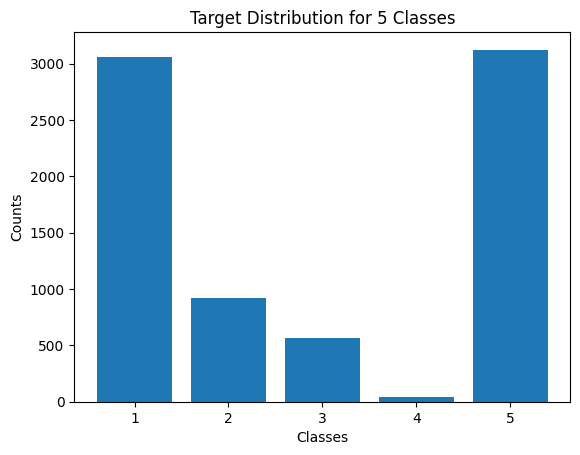

In [80]:
# initialize df w/ all classes 

encoded_df_all_classes = get_all_encodings(df, combined_classes=False)
counts = get_class_counts(encoded_df_all_classes)

There is major imbalance between the classes, as shown in the target distribution above. Classes 1 and 5 make up the majority of the dataset. We will address this by combining some classes, such that Class 1 = limited disability ("healthy"), Classes 2-4 = moderate disability, and Class 5 = death. From a clinical standpoint, this can still be a useful indicator of patient status, despite the decreased resolution. Before we can combine target columns, we must first determine whether the classes are truly similar via cosine similarity comparison. 

In [81]:
features = encoded_df_all_classes.drop(columns=['sfdm2'])
target = encoded_df_all_classes['sfdm2']

similarity_result = perform_cosine_similarity(features, target, classes=[2, 3, 4])
print(similarity_result) # classes are very similar, therefore we can combine classes 2-4

[[1.         0.99983048 0.99493264]
 [0.99983048 1.         0.9946089 ]
 [0.99493264 0.9946089  1.        ]]


Cosine similarity indicates that the classes are nearly identical. Therefore, we will combine classes 2-4 into one single class, and utilize the modified target labels as described above (Class 1, 2, 3). 

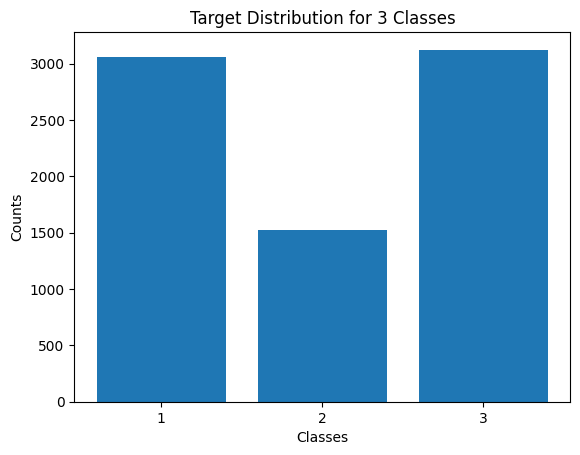

In [82]:
# from above, high similarity between classes 2, 3, 4 -> combine classes 
# re-encode df w/ 3 classes only 
encoded_df_3_classes = get_all_encodings(df, combined_classes=True)
counts = get_class_counts(encoded_df_3_classes)

In [83]:
# use final df w/ combined classes 
X_train, X_test, y_train, y_test = split_scale_impute(encoded_df_3_classes)

Contains missing values xtrain: False
Contains missing values xtest: False
Contains missing values ytrain: False
Contains missing values ytest: False


In [84]:
y_train.nunique() # confirm only 3 classes

sfdm2    3
dtype: int64

In [85]:
# visualize features with pairplot; determine whether correlation exists

# sns.pairplot(encoded_df_3_classes, diag_kind='kde', hue='sfdm2')
# plt.show()

The pairplot reveals there are no strong correlation between any set of features; all features are featureless clouds. We confirm this with a correlation heatmap: 

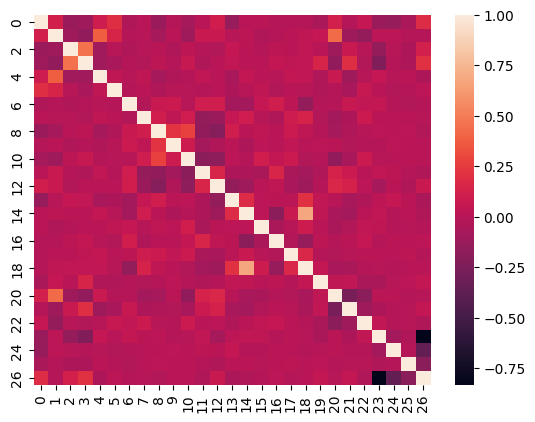

In [86]:
sns.heatmap(X_train.corr()) # there will be no class labels, but we expect there to be no correlation 
plt.show()

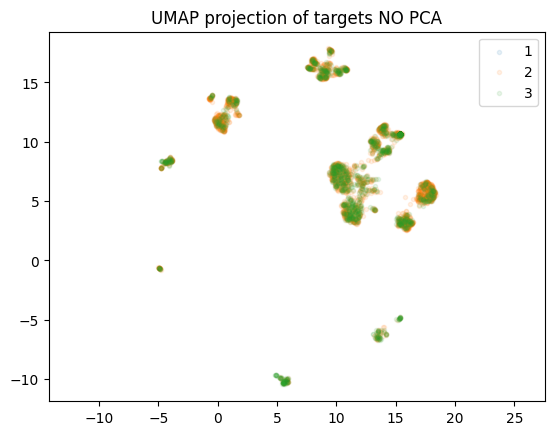

In [87]:
newXY = umap.UMAP().fit_transform(X_train)

for i in range(np.max(y_train)):
    idx = np.argwhere(y_train == i)
    plt.scatter(newXY[idx, 0], newXY[idx, 1], marker = '.',
                alpha = 0.1, label = str(i + 1))

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of targets NO PCA')
plt.legend()
plt.show()

The UMAP projection also suggests there is no distinct clustering for the different classes. All of the clusters seem to overlap with one another. We try PCA next to examine the eigenvalue spectrum: 

Eigenvalues and explained variance ratio:
  PC1: eigenvalue = 2.1632, explains 8.7% of variance
  PC2: eigenvalue = 2.0968, explains 8.4% of variance
  PC3: eigenvalue = 1.7471, explains 7.0% of variance
  PC4: eigenvalue = 1.5014, explains 6.0% of variance
  PC5: eigenvalue = 1.3812, explains 5.5% of variance
  PC6: eigenvalue = 1.1184, explains 4.5% of variance
  PC7: eigenvalue = 1.0891, explains 4.4% of variance
  PC8: eigenvalue = 1.0450, explains 4.2% of variance
  PC9: eigenvalue = 1.0242, explains 4.1% of variance
  PC10: eigenvalue = 1.0100, explains 4.1% of variance
  PC11: eigenvalue = 1.0034, explains 4.0% of variance
  PC12: eigenvalue = 0.9715, explains 3.9% of variance
  PC13: eigenvalue = 0.9394, explains 3.8% of variance
  PC14: eigenvalue = 0.8513, explains 3.4% of variance
  PC15: eigenvalue = 0.8294, explains 3.3% of variance
  PC16: eigenvalue = 0.7648, explains 3.1% of variance
  PC17: eigenvalue = 0.7412, explains 3.0% of variance
  PC18: eigenvalue = 0.6813, exp

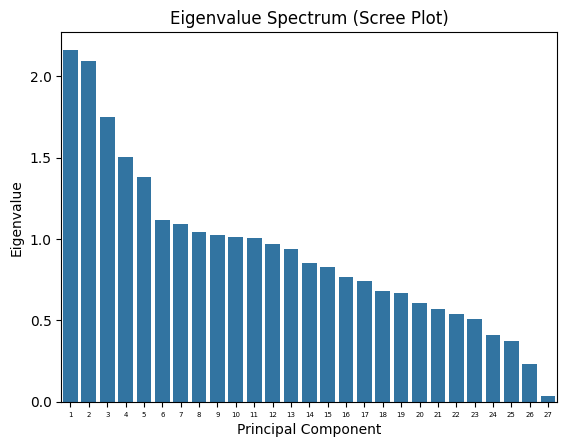

In [88]:
# examine PCA
pca = PCA()
pca.fit(X_train, y_train)

# Get eigenvalues (explained variance)
eigenvalues = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_

print("Eigenvalues and explained variance ratio:")
for i, (ev, ratio) in enumerate(zip(eigenvalues, explained_ratio)):
    print(f"  PC{i+1}: eigenvalue = {ev:.4f}, explains {ratio*100:.1f}% of variance")

print(f"\nTotal variance explained: {sum(explained_ratio)*100:.1f}%")

# Scree plot
sns.barplot(x=np.arange(1, np.max(len(eigenvalues)) + 1), y=eigenvalues)
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalue Spectrum (Scree Plot)')
plt.xticks(fontsize=5)
plt.show()

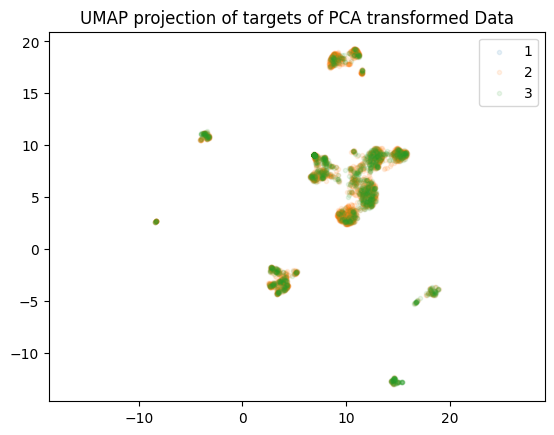

In [89]:
# refit PCA to keeping 97% of variance
pca = PCA(n_components=0.97)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

newXY = umap.UMAP().fit_transform(X_train_pca)

for i in range(np.max(y_train)):
    idx = np.argwhere(y_train == i)
    plt.scatter(newXY[idx, 0], newXY[idx, 1], marker = '.',
                alpha = 0.1, label = str(i + 1))

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of targets of PCA transformed Data')
plt.legend()
plt.show()

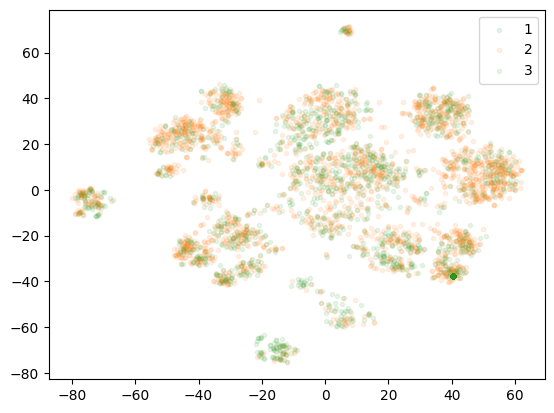

In [90]:
# PCA is not a good candidate for reducing dimensionality; try T-SNE instead 
tsne = TSNE(learning_rate='auto', init='random', perplexity=30, random_state=42)
newXY = tsne.fit_transform(X_train) 

# use train dataset to visualize dataset to see if there is any clustering 
for i in range(np.max(y_train)):
    idx = np.argwhere(y_train == i)
    plt.scatter(newXY[idx, 0], newXY[idx, 1], marker = '.',
                alpha = 0.1, label = str(i + 1))

plt.legend()
plt.show()

In [91]:
# save accuries and entropies
model_accuracies = {
    'MN_LogReg': 0,
    'Naive_Bayes': 0,
}
model_entropies = {
    'MN_LogReg': 0,
    'Leiden_clustering': 0,
    'Naive_Bayes': 0,
    'GMM': 0
}

---------------------------- MN LOGISTIC REGRESSION ----------------------------
training accuracy: 49.71%
testing accuracy: 50.42%
MN Logistic Regression Accuracy: training accuracy: 49.71% | "testing accuracy: 50.42%


/var/folders/k6/xhf7ptrj2fq9f0n268zjy48m0000gn/T/ipykernel_13290/2350515722.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0].scatter(newXY[idx, 0], newXY[idx, 1], marker = '.',
/var/folders/k6/xhf7ptrj2fq9f0n268zjy48m0000gn/T/ipykernel_13290/2350515722.py:28: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(newXY[idx, 0], newXY[idx, 1], marker = '.',


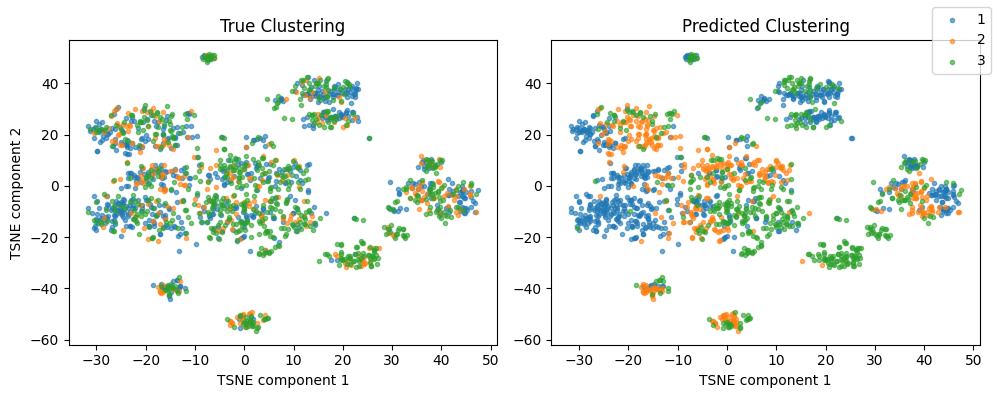

MN Logistic Regression Entropy: 0.9277993102460789


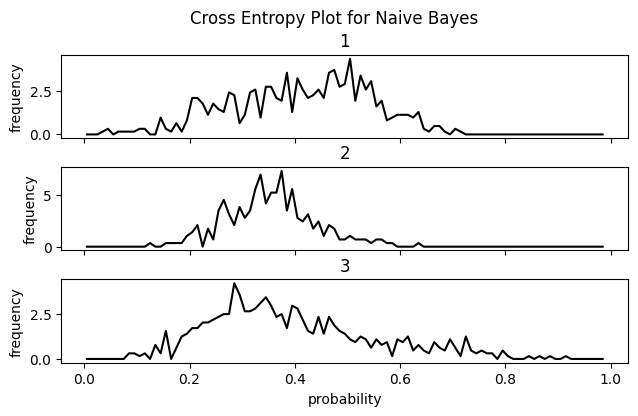

In [92]:
# WITH PCA

print(f'---------------------------- MN LOGISTIC REGRESSION ----------------------------')
MN_LogReg = MN_Logistic_Regression_model(num_classes=3,
                                         x_train=X_train_pca,
                                         y_train=y_train,
                                         x_test=X_test_pca,
                                         y_test=y_test,
                                         balance_classes=True)

# accuracies
acc = MN_LogReg.get_accuracies()
print(f'MN Logistic Regression Accuracy: {acc}')
model_accuracies['MN_LogReg'] = acc

# plot t-SNE
MN_LogReg.visualize_clustering()

# entropy
avg_MNLogreg_entropy = MN_LogReg.get_entropy()
print(f'MN Logistic Regression Entropy: {avg_MNLogreg_entropy}')
model_entropies['MN_LogReg'] = avg_MNLogreg_entropy
MN_LogReg.plot_entropy()

---------------------------- LEIDEN CLUSTERING ----------------------------


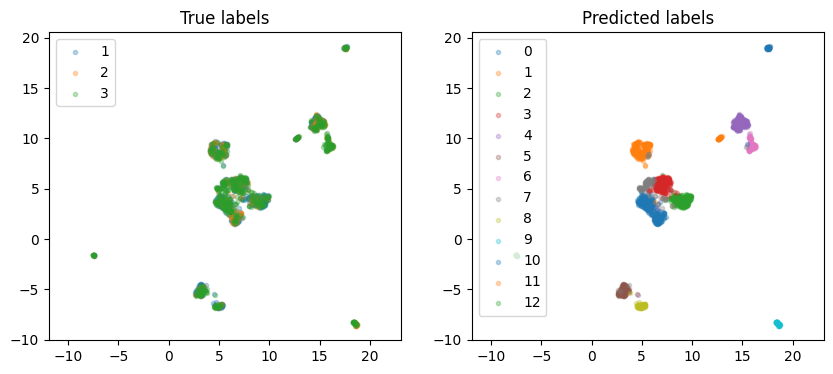

Leiden Clustering Average Entropy: 0.012701816451730836


In [93]:
print(f'---------------------------- LEIDEN CLUSTERING ----------------------------')
Leiden = Leiden_clustering(k=15,
                            x_data=X_test_pca,
                            y_data=y_test)

# visualize with UMAP
Leiden.get_UMAP()

# entropies
avg_leiden_entropy = Leiden.get_entropy()
print(f'Leiden Clustering Average Entropy: {avg_leiden_entropy}')
model_entropies['Leiden_clustering'] = avg_leiden_entropy

---------------------------- GAUSSIAN MIXTURE MODEL ----------------------------


/var/folders/k6/xhf7ptrj2fq9f0n268zjy48m0000gn/T/ipykernel_13290/2350515722.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0].scatter(newXY[idx, 0], newXY[idx, 1], marker = '.',
/var/folders/k6/xhf7ptrj2fq9f0n268zjy48m0000gn/T/ipykernel_13290/2350515722.py:28: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(newXY[idx, 0], newXY[idx, 1], marker = '.',


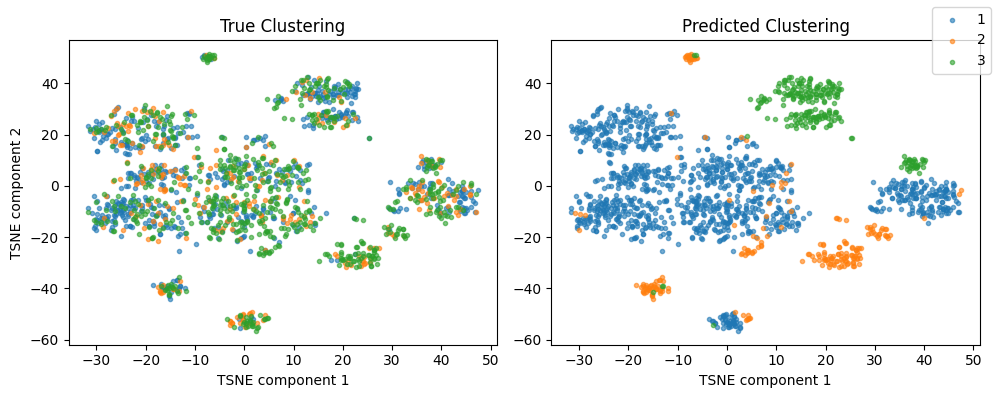

GMM Clustering Average Entropy: 0.000785691082798711


In [94]:
print(f'---------------------------- GAUSSIAN MIXTURE MODEL ----------------------------')
GMM = Gaussian_Mixture_model(num_components=3,
                             rand_state=0,
                             x_data=X_test_pca,
                             y_data=y_test,
                             target='sfdm2')

# visualize with UMAP
GMM.visualize_clustering()

# entropies
gmm_entropy = GMM.get_entropy()
print(f'GMM Clustering Average Entropy: {gmm_entropy}')
model_entropies['GMM'] = gmm_entropy

---------------------------- NAIVE BAYES ----------------------------
training accuracy: 47.81%
testing accuracy: 48.86%
Naive Bayes Accuracy: training accuracy: 47.81% | "testing accuracy: 48.86%


/var/folders/k6/xhf7ptrj2fq9f0n268zjy48m0000gn/T/ipykernel_13290/2350515722.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0].scatter(newXY[idx, 0], newXY[idx, 1], marker = '.',
/var/folders/k6/xhf7ptrj2fq9f0n268zjy48m0000gn/T/ipykernel_13290/2350515722.py:28: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(newXY[idx, 0], newXY[idx, 1], marker = '.',


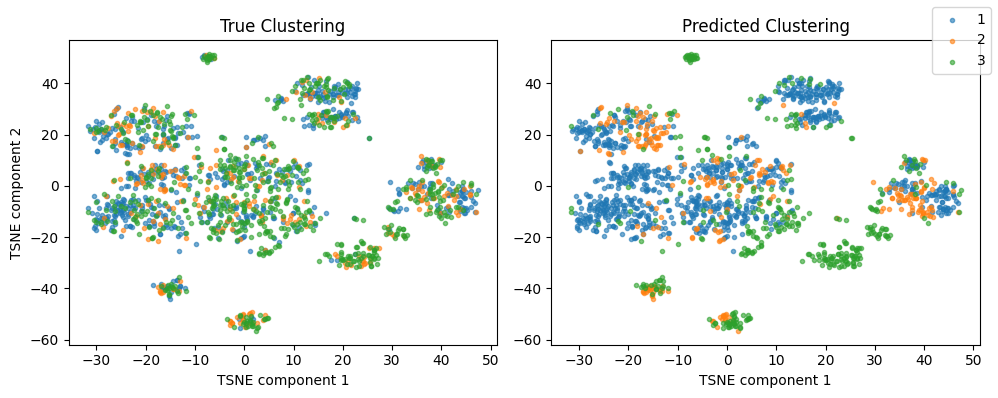

Average Entropy for Naive Bayes Model: 0.7826760488341371


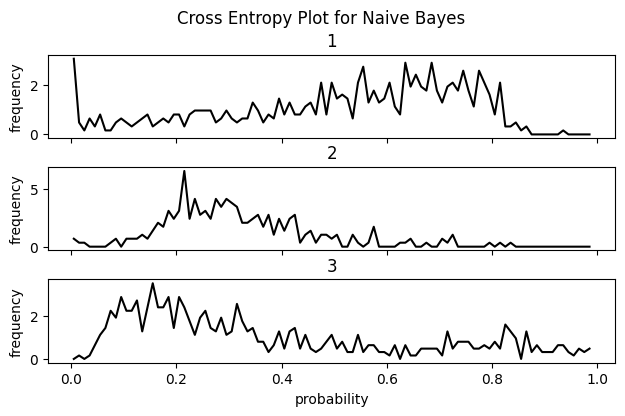

In [95]:
print(f'---------------------------- NAIVE BAYES ----------------------------')
NB = Naive_Bayes_model(num_classes=3,
                        x_train=X_train_pca,
                        y_train=y_train,
                        x_test=X_test_pca,
                        y_test=y_test,
                        update_priors=True)

# accuracies
acc = NB.get_accuracies()
print(f'Naive Bayes Accuracy: {acc}')
model_accuracies['Naive_Bayes'] = acc

# visualize t-SNE
NB.visualize_clustering()

# entropies
avg_NB_entropy = NB.get_entropy()
print(f'Average Entropy for Naive Bayes Model: {avg_NB_entropy}')
model_entropies['Naive_Bayes'] = avg_NB_entropy
NB.plot_entropy()

In [96]:
print('============ MODEL ACCURACIES =============')
print(model_accuracies)
print('============ MODEL ENTROPIES =============')
print(model_entropies)

============ MODEL ACCURACIES =============
{'MN_LogReg': 'training accuracy: 49.71% | "testing accuracy: 50.42%', 'Naive_Bayes': 'training accuracy: 47.81% | "testing accuracy: 48.86%'}
============ MODEL ENTROPIES =============
{'MN_LogReg': np.float64(0.9277993102460789), 'Leiden_clustering': np.float64(0.012701816451730836), 'Naive_Bayes': np.float64(0.7826760488341371), 'GMM': np.float64(0.000785691082798711)}


## Discussion: interpret results, discuss model limitations and improvements

## Contribution<br>
Andy: Unsupervised modeling + fine tuning, data evaluation <br>
Anika: Data preprocessing, visualization, data evaluation <br>
Kara: Dataset selection, EDA, feature selection, limitations & improvements <br>
Yashesha: Supervised modeling + fine tuning, data evaluation <br>

## References

Hoayek, A., & Rullière, D. (2024). Assessing clustering methods using Shannon’s entropy. Information Sciences, 689, 121510. https://doi.org/10.1016/j.ins.2024.121510